# Analisis Komparatif Strategi Algoritma Trading Berbasis Indikator Teknikal
## EMA, RSI, dan MACD pada Indeks Utama AS (S&P 500, NASDAQ 100, Dow Jones)

**Notebook Riset Kuantitatif — Tugas Akhir (Skripsi)**

---

Notebook ini mengimplementasikan sistem trading deterministik berbasis **Trend-Following with Pullback**
(membeli saat koreksi sehat searah tren, bukan mengejar harga di zona overbought/oversold ekstrem)
dengan aturan dual-direction (Long & Short) pada data 1-hour (H1) tiga indeks utama AS.

In [18]:
# =============================================================================
# SEL 1: ENVIRONMENT SETUP & INSTALASI LIBRARY
# =============================================================================
# Instalasi dependensi utama yang dibutuhkan untuk analisis kuantitatif.
# - pandas      : Manipulasi data tabular dan time-series.
# - numpy       : Operasi numerik dan array.
# - pyarrow     : Backend I/O untuk format Parquet.
# - matplotlib  : Visualisasi grafik ilmiah.
# - seaborn     : Ekstensi estetika visualisasi matplotlib.

!pip install pandas numpy pyarrow matplotlib seaborn


[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: C:\Users\Administrator\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [25]:
# =============================================================================
# SEL 2: IMPORT LIBRARY & FUNGSI PEMROSESAN DATA UNIVERSAL
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Konfigurasi tampilan dan gaya visualisasi
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)


def proses_data_instrumen(filepath):
    """
    Fungsi modular untuk memuat dan memproses data instrumen keuangan.
    Mendukung format Parquet dan CSV tab-separated secara otomatis.
    
    Tahapan pemrosesan:
    1. Deteksi format file (Parquet / CSV tab-separated).
    2. Standarisasi nama kolom (lowercase, strip whitespace).
    3. Konversi kolom waktu ke DatetimeIndex.
    4. Pengurutan kronologis menaik.
    5. Kalkulasi indikator teknikal: EMA (50, 100, 200), MACD (12, 26, 9), RSI (14).
    6. Pembersihan baris NaN akibat periode lookback indikator.
    
    Parameters
    ----------
    filepath : str
        Path ke file data (Parquet atau CSV).
    
    Returns
    -------
    pd.DataFrame
        DataFrame terproses dengan indikator teknikal dan DatetimeIndex.
    """
    # --- Tahap 1: Deteksi format dan muat data ---
    if filepath.endswith('.parquet'):
        df = pd.read_parquet(filepath)
    else:
        df = pd.read_csv(filepath, sep='\t')
    
    # --- Tahap 2: Standarisasi nama kolom ---
    df.columns = df.columns.str.strip().str.lower()
    
    # --- Tahap 3: Konversi kolom waktu ke DatetimeIndex ---
    if 'datetime' in df.columns:
        df['datetime'] = pd.to_datetime(df['datetime'])
        df.set_index('datetime', inplace=True)
    elif 'date' in df.columns and 'time' in df.columns:
        df['datetime'] = pd.to_datetime(df['date'].astype(str) + ' ' + df['time'].astype(str))
        df.set_index('datetime', inplace=True)
        df.drop(columns=['date', 'time'], inplace=True, errors='ignore')
    else:
        raise ValueError(f"Kolom datetime tidak ditemukan pada file: {filepath}")
    
    # Hapus kolom non-OHLC yang tidak dibutuhkan
    kolom_pertahankan = ['open', 'high', 'low', 'close', 'volume']
    kolom_tersedia = [k for k in kolom_pertahankan if k in df.columns]
    df = df[kolom_tersedia]
    
    # --- Tahap 4: Pengurutan kronologis menaik ---
    df.sort_index(inplace=True)
    
    # --- Tahap 5: Kalkulasi Indikator Teknikal ---
    
    # 5a. EMA (Exponential Moving Average) — span 50, 100, 200
    df['ema_50'] = df['close'].ewm(span=50, adjust=False).mean()
    df['ema_100'] = df['close'].ewm(span=100, adjust=False).mean()
    df['ema_200'] = df['close'].ewm(span=200, adjust=False).mean()
    
    # 5b. MACD (Moving Average Convergence Divergence)
    #     Fast EMA (span=12), Slow EMA (span=26), Signal Line (span=9)
    ema_fast = df['close'].ewm(span=12, adjust=False).mean()
    ema_slow = df['close'].ewm(span=26, adjust=False).mean()
    df['macd_line'] = ema_fast - ema_slow
    df['macd_signal'] = df['macd_line'].ewm(span=9, adjust=False).mean()
    
    # 5c. RSI (Relative Strength Index) — Wilder's Smoothing, periode 14
    #     Menggunakan alpha = 1/14 sesuai metode standar Wilder.
    delta = df['close'].diff()
    gain = delta.clip(lower=0)
    loss = (-delta).clip(lower=0)
    
    avg_gain = gain.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    
    rs = avg_gain / avg_loss
    df['rsi'] = 100 - (100 / (1 + rs))
    
    # --- Tahap 6: Pembersihan baris NaN ---
    df.dropna(inplace=True)
    
    return df


print("[OK] Fungsi proses_data_instrumen() berhasil didefinisikan.")
print("     Mendukung: Parquet, CSV (tab-separated)")
print("     Indikator: EMA(50,100,200), MACD(12,26,9), RSI(14)")

[OK] Fungsi proses_data_instrumen() berhasil didefinisikan.
     Mendukung: Parquet, CSV (tab-separated)
     Indikator: EMA(50,100,200), MACD(12,26,9), RSI(14)


In [26]:
# =============================================================================
# SEL 3: PEMUATAN DATA PER INSTRUMEN INDEKS
# =============================================================================
# Memproses tiga instrumen utama AS menggunakan fungsi universal.
# Path menggunakan forward-slash agar kompatibel lintas OS (Windows/Linux).

# --- S&P 500 (SPY ETF) — Format Parquet ---
print("Memproses S&P 500 (SPY)...")
df_spy = proses_data_instrumen('TA/spy_US500_H1.parquet')
print(f"  Baris: {len(df_spy):,} | Periode: {df_spy.index.min()} s/d {df_spy.index.max()}")

# --- NASDAQ 100 — Format CSV Tab-Separated ---
print("\nMemproses NASDAQ 100...")
df_ndx = proses_data_instrumen('TA/Nasdaq100_1h_data.csv')
print(f"  Baris: {len(df_ndx):,} | Periode: {df_ndx.index.min()} s/d {df_ndx.index.max()}")

# --- Dow Jones Industrial Average — Format CSV Tab-Separated ---
print("\nMemproses Dow Jones (DJI)...")
df_dji = proses_data_instrumen('TA/Dow_Jones_1h_data.csv')
print(f"  Baris: {len(df_dji):,} | Periode: {df_dji.index.min()} s/d {df_dji.index.max()}")

print("\n" + "="*60)
print("[OK] Seluruh instrumen berhasil dimuat dan diproses.")

Memproses S&P 500 (SPY)...
  Baris: 50,158 | Periode: 2018-02-20 10:00:00 s/d 2026-08-19 11:00:00

Memproses NASDAQ 100...
  Baris: 51,875 | Periode: 2016-11-15 20:00:00 s/d 2025-10-01 07:00:00

Memproses Dow Jones (DJI)...
  Baris: 49,311 | Periode: 2016-10-27 15:00:00 s/d 2025-07-15 20:00:00

[OK] Seluruh instrumen berhasil dimuat dan diproses.


In [27]:
# =============================================================================
# SEL 4: PENYELARASAN TIMELINE (STRICT TIMELINE INTERSECTION)
# =============================================================================
# Ketiga instrumen memiliki jam perdagangan dan anomali bar libur yang
# sedikit berbeda. Analisis komparatif HANYA valid pada irisan timestamp
# yang identik di ketiga instrumen.
#
# Target: 41.653 baris data seragam, periode Februari 2018 — Juli 2025.

# Hitung irisan timestamp tiga arah
common_timeline = (
    df_spy.index
    .intersection(df_ndx.index)
    .intersection(df_dji.index)
)
common_timeline = common_timeline.sort_values()

# Reindex setiap instrumen ke irisan bersama
df_spy_final = df_spy.loc[common_timeline].copy()
df_ndx_final = df_ndx.loc[common_timeline].copy()
df_dji_final = df_dji.loc[common_timeline].copy()

# --- Validasi Hasil Penyelarasan ---
print("=" * 60)
print("VALIDASI PENYELARASAN TIMELINE")
print("=" * 60)
print(f"Jumlah bar irisan bersama  : {len(common_timeline):,}")
print(f"Tanggal awal               : {common_timeline.min()}")
print(f"Tanggal akhir              : {common_timeline.max()}")
print(f"\nBaris SPY final            : {len(df_spy_final):,}")
print(f"Baris NASDAQ final         : {len(df_ndx_final):,}")
print(f"Baris DJI final            : {len(df_dji_final):,}")

# Verifikasi kesamaan jumlah baris
assert len(df_spy_final) == len(df_ndx_final) == len(df_dji_final), \
    "ERROR: Jumlah baris ketiga instrumen tidak seragam setelah alignment!"

print(f"\n[OK] Ketiga instrumen selaras sempurna: {len(df_spy_final):,} baris.")
print(f"     Rentang: {common_timeline.min()} — {common_timeline.max()}")

VALIDASI PENYELARASAN TIMELINE
Jumlah bar irisan bersama  : 41,641
Tanggal awal               : 2018-02-20 10:00:00
Tanggal akhir              : 2025-07-15 20:00:00

Baris SPY final            : 41,641
Baris NASDAQ final         : 41,641
Baris DJI final            : 41,641

[OK] Ketiga instrumen selaras sempurna: 41,641 baris.
     Rentang: 2018-02-20 10:00:00 — 2025-07-15 20:00:00


In [28]:
# =============================================================================
# SEL 5: MESIN STRATEGI KUANTITATIF (QUANTITATIVE STRATEGY ENGINE)
# =============================================================================
# Implementasi sistem trading deterministik Long & Short dual-direction
# berbasis filosofi "Trend-Following with Pullback":
#   - Membeli saat koreksi sehat searah tren (RSI pullback ke level 50),
#     bukan mengejar harga di zona overbought/oversold ekstrem.
#
# Fitur utama:
#   - Sinyal Long (+1), Short (-1), dan Flat (0) dengan aturan exit eksplisit.
#   - Eksekusi menggunakan shift(1) untuk menghindari lookahead bias.
#   - Biaya transaksi realistis 0.02% (2 bps) setiap pergantian posisi.
#   - Tracking drawdown peak-to-trough.
#   - Log transaksi untuk audit akademis.


def simulasi_strategi(df, nama_instrumen, biaya=0.0002):
    """
    Menjalankan simulasi strategi trading Long & Short dengan logika Pullback.
    
    Aturan Entry (Pullback Logic):
    - LONG  (+1): EMA50 > EMA100 > EMA200 (uptrend),
                  RSI cross above 50 (pullback recovery),
                  MACD Line > Signal Line (momentum terkonfirmasi).
    - SHORT (-1): EMA200 > EMA100 > EMA50 (downtrend),
                  RSI cross below 50 (pullback recovery bearish),
                  MACD Line < Signal Line (momentum terkonfirmasi).
    
    Aturan Exit (Take Profit / Stop):
    - Exit Long  (→ 0): RSI >= 70 (overbought) ATAU EMA50 < EMA100 (tren melemah).
    - Exit Short (→ 0): RSI <= 30 (oversold)    ATAU EMA50 > EMA100 (tren berbalik).
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame dengan kolom indikator teknikal (ema, rsi, macd).
    nama_instrumen : str
        Nama instrumen untuk identifikasi output.
    biaya : float, default=0.0002
        Biaya transaksi per eksekusi (0.02% = 2 basis points).
    
    Returns
    -------
    dict
        Dictionary berisi:
        - 'nama': nama instrumen
        - 'return_strategi': pd.Series return per-bar strategi (setelah biaya)
        - 'return_kumulatif': pd.Series equity curve strategi
        - 'return_bnh': pd.Series equity curve buy-and-hold
        - 'drawdown': pd.Series profil drawdown strategi
        - 'log_transaksi': pd.DataFrame log entry/exit
        - 'posisi': pd.Series posisi aktif per bar
    """
    data = df.copy()
    
    # === KOMPONEN SINYAL ===
    
    # --- Filter Tren ---
    # Uptrend terkonfirmasi: EMA_50 > EMA_100 > EMA_200
    tren_naik = (data['ema_50'] > data['ema_100']) & (data['ema_100'] > data['ema_200'])
    # Downtrend terkonfirmasi: EMA_200 > EMA_100 > EMA_50
    tren_turun = (data['ema_200'] > data['ema_100']) & (data['ema_100'] > data['ema_50'])
    
    # --- Pemicu RSI Pullback ---
    # RSI cross above 50: RSI bergerak dari bawah ke atas level netral (pullback selesai)
    rsi_cross_above_50 = (data['rsi'].shift(1) <= 50) & (data['rsi'] > 50)
    # RSI cross below 50: RSI bergerak dari atas ke bawah level netral (pullback bearish)
    rsi_cross_below_50 = (data['rsi'].shift(1) >= 50) & (data['rsi'] < 50)
    
    # --- Konfirmasi Momentum MACD ---
    macd_bullish = data['macd_line'] > data['macd_signal']
    macd_bearish = data['macd_line'] < data['macd_signal']
    
    # === SINYAL ENTRY ===
    sinyal_long  = tren_naik  & rsi_cross_above_50 & macd_bullish  # → posisi +1
    sinyal_short = tren_turun & rsi_cross_below_50 & macd_bearish  # → posisi -1
    
    # === SINYAL EXIT ===
    # Exit Long: RSI mencapai zona overbought (>=70) ATAU tren melemah (EMA50 < EMA100)
    exit_long  = (data['rsi'] >= 70) | (data['ema_50'] < data['ema_100'])
    # Exit Short: RSI mencapai zona oversold (<=30) ATAU tren berbalik (EMA50 > EMA100)
    exit_short = (data['rsi'] <= 30) | (data['ema_50'] > data['ema_100'])
    
    # === KONSTRUKSI POSISI (Bar-by-Bar State Machine) ===
    # Iterasi deterministik untuk menghindari konflik sinyal simultan.
    # Posisi: +1 (Long), -1 (Short), 0 (Flat/Netral).
    posisi = pd.Series(0.0, index=data.index, dtype=float)
    pos_saat_ini = 0.0
    
    for i in range(len(data)):
        if pos_saat_ini == 0:
            # Sedang flat — cek sinyal entry
            if sinyal_long.iloc[i]:
                pos_saat_ini = 1.0
            elif sinyal_short.iloc[i]:
                pos_saat_ini = -1.0
        elif pos_saat_ini == 1:
            # Sedang long — cek sinyal exit long
            if exit_long.iloc[i]:
                pos_saat_ini = 0.0
        elif pos_saat_ini == -1:
            # Sedang short — cek sinyal exit short
            if exit_short.iloc[i]:
                pos_saat_ini = 0.0
        
        posisi.iloc[i] = pos_saat_ini
    
    data['posisi'] = posisi
    
    # === KALKULASI RETURN ===
    # Return pasar bar-ke-bar (persentase perubahan close)
    return_pasar = data['close'].pct_change()
    
    # Biaya transaksi: dikenakan setiap kali terjadi perubahan posisi
    trade_exec = data['posisi'].diff().abs().fillna(0)
    
    # Return strategi: posisi bar SEBELUMNYA × return bar BERJALAN - biaya
    # Menghindari lookahead bias — keputusan dibuat di bar t-1,
    # dampaknya baru terasa di bar t.
    return_strategi = data['posisi'].shift(1) * return_pasar - (trade_exec * biaya)
    return_strategi = return_strategi.fillna(0)
    
    # === EQUITY CURVE (Return Kumulatif) ===
    return_kumulatif = (1 + return_strategi).cumprod()
    
    # Buy & Hold sebagai benchmark
    return_bnh = (1 + return_pasar.fillna(0)).cumprod()
    
    # === DRAWDOWN ===
    # Penurunan modal dari puncak tertinggi (peak-to-trough)
    peak_kumulatif = return_kumulatif.cummax()
    drawdown = (return_kumulatif - peak_kumulatif) / peak_kumulatif
    
    # === LOG TRANSAKSI ===
    # Mencatat setiap perubahan posisi sebagai entry/exit
    perubahan = data['posisi'].diff().fillna(data['posisi'])
    mask_transaksi = perubahan != 0
    
    log = data.loc[mask_transaksi, ['close', 'rsi', 'macd_line', 'macd_signal', 'posisi']].copy()
    log['aksi'] = log['posisi'].map({1: 'LONG ENTRY', -1: 'SHORT ENTRY', 0: 'EXIT (FLAT)'})
    log['aksi'] = log['aksi'].fillna('POSISI BERUBAH')
    
    print(f"  [{nama_instrumen}] Strategi selesai — "
          f"Total sinyal: {mask_transaksi.sum()}, "
          f"Return akhir: {return_kumulatif.iloc[-1]:.4f}x")
    
    return {
        'nama': nama_instrumen,
        'return_strategi': return_strategi,
        'return_kumulatif': return_kumulatif,
        'return_bnh': return_bnh,
        'drawdown': drawdown,
        'log_transaksi': log,
        'posisi': data['posisi']
    }


# --- Eksekusi Strategi untuk Ketiga Instrumen ---
print("Menjalankan simulasi strategi kuantitatif (Pullback Logic)...\n")

hasil_spy = simulasi_strategi(df_spy_final, 'S&P 500 (SPY)')
hasil_ndx = simulasi_strategi(df_ndx_final, 'NASDAQ 100')
hasil_dji = simulasi_strategi(df_dji_final, 'Dow Jones (DJI)')

daftar_hasil = [hasil_spy, hasil_ndx, hasil_dji]

print("\n" + "="*60)
print("[OK] Simulasi strategi selesai untuk seluruh instrumen.")

Menjalankan simulasi strategi kuantitatif (Pullback Logic)...

  [S&P 500 (SPY)] Strategi selesai — Total sinyal: 548, Return akhir: 0.9630x
  [NASDAQ 100] Strategi selesai — Total sinyal: 572, Return akhir: 0.7054x
  [Dow Jones (DJI)] Strategi selesai — Total sinyal: 554, Return akhir: 1.1022x

[OK] Simulasi strategi selesai untuk seluruh instrumen.


In [29]:
# =============================================================================
# SEL 6: TABEL EVALUASI KINERJA (PERFORMANCE METRICS TABLE)
# =============================================================================
# Menghitung metrik finansial standar riset akademik untuk evaluasi
# komparatif ketiga instrumen.
#
# Asumsi:
#   - Data H1 (1-jam), 7 bar per hari perdagangan × 252 hari = 1.764 bar/tahun.
#   - Risk-free rate = 0%.
#   - Biaya transaksi sudah terinternalisasi dalam return strategi.

BARS_PER_TAHUN = 252 * 7  # 1.764 bar H1 per tahun


def hitung_metrik(hasil, bars_per_tahun=BARS_PER_TAHUN):
    """
    Menghitung metrik kinerja kuantitatif komprehensif.
    
    Metrik yang dihitung:
    1. Total Cumulative Return (%)
    2. CAGR (%)
    3. Annualized Volatility (%)
    4. Sharpe Ratio (Risk-Free Rate = 0%)
    5. Sortino Ratio (Downside deviation only)
    6. Maximum Drawdown (%)
    7. Win Rate (%) — per siklus trade selesai (entry-to-exit)
    8. Profit Factor — Gross Profit / Gross Loss
    9. Total Trades — Jumlah siklus transaksi selesai
    
    Parameters
    ----------
    hasil : dict
        Output dari fungsi simulasi_strategi().
    bars_per_tahun : int
        Jumlah bar per tahun untuk annualisasi (default: 1.764).
    
    Returns
    -------
    dict
        Dictionary metrik kinerja.
    """
    ret = hasil['return_strategi']
    cum = hasil['return_kumulatif']
    dd = hasil['drawdown']
    posisi = hasil['posisi']
    
    # 1. Total Cumulative Return
    total_return = cum.iloc[-1] - 1
    
    # 2. CAGR (Compound Annual Growth Rate)
    total_bars = len(ret)
    total_tahun = total_bars / bars_per_tahun
    cagr = (cum.iloc[-1] ** (1 / total_tahun)) - 1 if total_tahun > 0 else 0
    
    # 3. Annualized Volatility
    vol_tahunan = ret.std() * np.sqrt(bars_per_tahun)
    
    # 4. Annualized Sharpe Ratio (risk-free rate = 0%)
    sharpe = (ret.mean() / ret.std()) * np.sqrt(bars_per_tahun) if ret.std() > 0 else 0
    
    # 5. Annualized Sortino Ratio (hanya downside deviation)
    downside_ret = ret[ret < 0]
    downside_std = downside_ret.std() if len(downside_ret) > 0 else 0
    sortino = (ret.mean() / downside_std) * np.sqrt(bars_per_tahun) if downside_std > 0 else 0
    
    # 6. Maximum Drawdown
    max_drawdown = dd.min()
    
    # 7–9. Metrik berbasis siklus transaksi selesai (trade-level)
    # Identifikasi setiap siklus transaksi entry→exit sebagai satu trade selesai.
    # Satu trade dimulai saat posisi berubah dari 0 ke ±1, dan berakhir saat
    # posisi kembali ke 0.
    perubahan = posisi.diff().fillna(posisi)
    idx_perubahan = perubahan[perubahan != 0].index
    
    trade_returns = []
    i = 0
    while i < len(idx_perubahan):
        pos_val = posisi.loc[idx_perubahan[i]]
        if pos_val != 0:
            # Ini adalah entry — cari exit berikutnya (posisi = 0)
            start = idx_perubahan[i]
            exit_found = False
            for j in range(i + 1, len(idx_perubahan)):
                if posisi.loc[idx_perubahan[j]] == 0:
                    end = idx_perubahan[j]
                    # Return kumulatif per siklus trade
                    trade_ret = ret.loc[start:end]
                    trade_cum = (1 + trade_ret).prod() - 1
                    trade_returns.append(trade_cum)
                    i = j + 1
                    exit_found = True
                    break
            if not exit_found:
                # Trade masih terbuka (belum ada exit) — hitung sampai akhir data
                trade_ret = ret.loc[start:]
                trade_cum = (1 + trade_ret).prod() - 1
                trade_returns.append(trade_cum)
                break
        else:
            i += 1
    
    trade_returns = np.array(trade_returns)
    total_trades = len(trade_returns)
    
    # Win Rate
    winning = trade_returns[trade_returns > 0]
    win_rate = len(winning) / total_trades * 100 if total_trades > 0 else 0
    
    # Profit Factor (Gross Profit / Gross Loss)
    gross_profit = winning.sum() if len(winning) > 0 else 0
    losing = trade_returns[trade_returns < 0]
    gross_loss = abs(losing.sum()) if len(losing) > 0 else 1e-10  # Hindari div-by-zero
    profit_factor = gross_profit / gross_loss
    
    return {
        'Instrumen': hasil['nama'],
        'Total Cumulative Return (%)': total_return * 100,
        'CAGR (%)': cagr * 100,
        'Annualized Volatility (%)': vol_tahunan * 100,
        'Sharpe Ratio': sharpe,
        'Sortino Ratio': sortino,
        'Max Drawdown (%)': max_drawdown * 100,
        'Win Rate (%)': win_rate,
        'Profit Factor': profit_factor,
        'Total Trades': total_trades
    }


# --- Kompilasi Tabel Metrik ---
metrik_list = [hitung_metrik(h) for h in daftar_hasil]
df_metrik = pd.DataFrame(metrik_list).set_index('Instrumen')

print("=" * 80)
print("RINGKASAN KINERJA KOMPARATIF — STRATEGI PULLBACK (EMA/RSI/MACD)")
print("Periode Analisis:", common_timeline.min().strftime('%Y-%m-%d'),
      "s/d", common_timeline.max().strftime('%Y-%m-%d'))
print(f"Jumlah Bar: {len(common_timeline):,} | Biaya: 0.02% per eksekusi")
print("=" * 80)
print()
print(df_metrik.to_string())
print()

RINGKASAN KINERJA KOMPARATIF — STRATEGI PULLBACK (EMA/RSI/MACD)
Periode Analisis: 2018-02-20 s/d 2025-07-15
Jumlah Bar: 41,641 | Biaya: 0.02% per eksekusi

                 Total Cumulative Return (%)  CAGR (%)  Annualized Volatility (%)  Sharpe Ratio  Sortino Ratio  Max Drawdown (%)  Win Rate (%)  Profit Factor  Total Trades
Instrumen                                                                                                                                                                  
S&P 500 (SPY)                        -3.7010   -0.1596                     4.4790       -0.0133        -0.0079          -17.8030       55.1095         0.9919           274
NASDAQ 100                          -29.4642   -1.4678                     6.3261       -0.2021        -0.1084          -36.5959       51.3986         0.8592           286
Dow Jones (DJI)                      10.2157    0.4129                     4.1395        0.1202         0.0732          -18.9233       54.5126         1.090

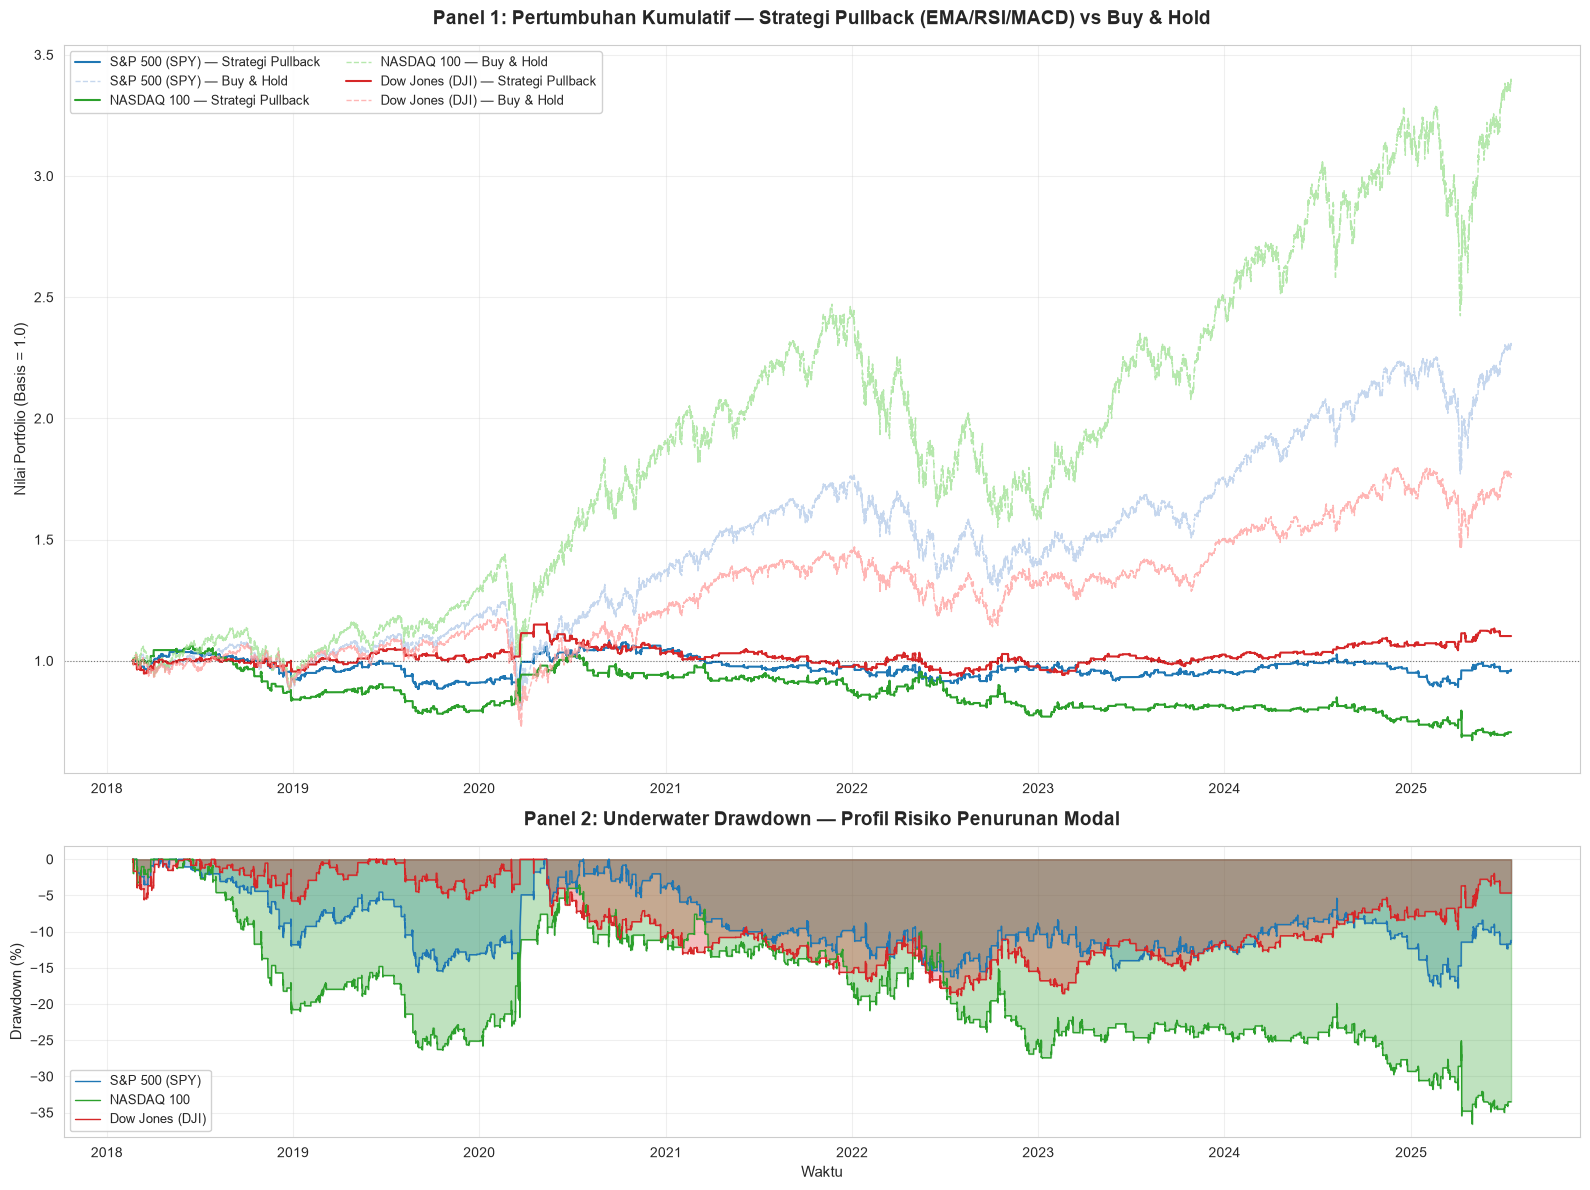

[OK] Grafik disimpan: equity_drawdown_chart.png

SAMPEL LOG TRANSAKSI (10 Entri Terakhir) — Untuk Lampiran Tesis

--- S&P 500 (SPY) ---
Total transaksi tercatat: 548
                        Close  RSI(14)  MACD Line  Posisi         Aksi
datetime                                                              
2025-06-06 14:00:00 5960.9000  51.1874    -0.7251  1.0000   LONG ENTRY
2025-06-06 16:00:00 6010.8500  70.8205     5.2000  0.0000  EXIT (FLAT)
2025-06-12 16:00:00 6015.8000  53.2287    -5.5060  1.0000   LONG ENTRY
2025-06-13 11:00:00 5969.6500  41.3789   -15.2255  0.0000  EXIT (FLAT)
2025-06-23 01:00:00 5950.1000  43.3467    -0.0235 -1.0000  SHORT ENTRY
2025-06-24 02:00:00 6057.7000  72.7145    19.7359  0.0000  EXIT (FLAT)
2025-07-07 12:00:00 6259.6000  59.8088     1.8017  1.0000   LONG ENTRY
2025-07-09 16:00:00 6265.2000  76.1703     3.7463  0.0000  EXIT (FLAT)
2025-07-14 16:00:00 6247.4000  54.4199    -3.0142  1.0000   LONG ENTRY
2025-07-15 04:00:00 6285.3000  70.7290     7.0547  0.

In [30]:
# =============================================================================
# SEL 7: VISUALISASI AKADEMIK & LOG AUDIT
# =============================================================================
# Panel 1: Grafik Pertumbuhan Kumulatif (Equity Curve) ketiga instrumen.
# Panel 2: Underwater Drawdown Chart (profil risiko penurunan modal).
# Sampel Log Transaksi: 10 transaksi terakhir per instrumen.

# --- Konfigurasi Warna Konsisten ---
WARNA = {
    'S&P 500 (SPY)': '#1f77b4',     # Biru
    'NASDAQ 100': '#2ca02c',         # Hijau
    'Dow Jones (DJI)': '#d62728'     # Merah
}
WARNA_BNH = {
    'S&P 500 (SPY)': '#aec7e8',     # Biru muda
    'NASDAQ 100': '#98df8a',         # Hijau muda
    'Dow Jones (DJI)': '#ff9896'     # Merah muda
}

# =====================================================================
# PANEL 1 & 2: EQUITY CURVE + DRAWDOWN (Height Ratio 2.5 : 1)
# =====================================================================
fig, axes = plt.subplots(2, 1, figsize=(16, 12),
                         gridspec_kw={'height_ratios': [2.5, 1]})

# --- Panel 1: Pertumbuhan Ekuitas Kumulatif ---
ax1 = axes[0]
for h in daftar_hasil:
    nama = h['nama']
    # Garis strategi (tebal, solid)
    ax1.plot(h['return_kumulatif'].index, h['return_kumulatif'].values,
             label=f"{nama} — Strategi Pullback",
             color=WARNA[nama], linewidth=1.5)
    # Garis buy-and-hold (tipis, dashed)
    ax1.plot(h['return_bnh'].index, h['return_bnh'].values,
             label=f"{nama} — Buy & Hold",
             color=WARNA_BNH[nama], linewidth=1.0, linestyle='--', alpha=0.7)

ax1.axhline(y=1, color='black', linestyle=':', linewidth=0.8, alpha=0.5)
ax1.set_title('Panel 1: Pertumbuhan Kumulatif — Strategi Pullback (EMA/RSI/MACD) vs Buy & Hold',
              fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('Nilai Portfolio (Basis = 1.0)', fontsize=11)
ax1.legend(loc='upper left', fontsize=9, ncol=2, framealpha=0.9)
ax1.grid(True, alpha=0.3)

# --- Panel 2: Underwater Drawdown ---
ax2 = axes[1]
for h in daftar_hasil:
    nama = h['nama']
    ax2.fill_between(h['drawdown'].index, h['drawdown'].values * 100, 0,
                     alpha=0.3, color=WARNA[nama])
    ax2.plot(h['drawdown'].index, h['drawdown'].values * 100,
             label=nama, color=WARNA[nama], linewidth=1.0)

ax2.set_title('Panel 2: Underwater Drawdown — Profil Risiko Penurunan Modal',
              fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel('Drawdown (%)', fontsize=11)
ax2.set_xlabel('Waktu', fontsize=11)
ax2.legend(loc='lower left', fontsize=9, framealpha=0.9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('equity_drawdown_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("[OK] Grafik disimpan: equity_drawdown_chart.png")


# =====================================================================
# SAMPEL LOG TRANSAKSI — 10 TRANSAKSI TERAKHIR PER INSTRUMEN
# =====================================================================
print("\n" + "=" * 80)
print("SAMPEL LOG TRANSAKSI (10 Entri Terakhir) — Untuk Lampiran Tesis")
print("=" * 80)

for h in daftar_hasil:
    log = h['log_transaksi']
    print(f"\n--- {h['nama']} ---")
    print(f"Total transaksi tercatat: {len(log)}")
    if len(log) > 0:
        tampilan = log.tail(10)[['close', 'rsi', 'macd_line', 'posisi', 'aksi']].copy()
        tampilan.columns = ['Close', 'RSI(14)', 'MACD Line', 'Posisi', 'Aksi']
        print(tampilan.to_string())
    else:
        print("  Tidak ada transaksi tercatat.")

print("\n" + "=" * 80)
print("[SELESAI] Seluruh analisis kuantitatif berhasil diselesaikan.")
print("=" * 80)